# Pakiza Hassan (fa23-bai-034)

In [30]:

#  INSTALL REQUIRED LIBRARIES


!pip -q install kagglehub scikit-image seaborn

In [31]:

#  IMPORT LIBRARIES


import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageEnhance, ImageFilter

import kagglehub

from skimage.feature import hog
from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:

# CHUNK 3: VISUALIZATION THEME


SAGE = "#7A9E7E"
DARK_SAGE = "#4F6F52"
BEIGE = "#F3EBDD"
PINK = "#D98C9B"
PURPLE = "#8E7DBE"
TEA = "#B89B72"
DARK = "#3E3E3E"
LIGHT = "#FAF8F3"

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.facecolor": LIGHT,
    "axes.facecolor": BEIGE,
    "axes.edgecolor": DARK,
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "text.color": DARK,
    "axes.titleweight": "bold",
    "figure.titlesize": 15
})

print("Visualization theme configured.")

Visualization theme configured.


In [4]:
# ============================================================
# CHUNK 4: DATASET INFORMATION
# ============================================================

DATASET_URL = (
    "https://www.kaggle.com/"
    "ravirajsinh45/real-life-industrial-dataset-of-casting-product"
)

print("Dataset:")
print("Casting Product Image Data for Quality Inspection")
print()
print("Dataset URL:")
print(DATASET_URL)
print()
print("Class 0: Non-Defective / OK")
print("Class 1: Defective")

Dataset:
Casting Product Image Data for Quality Inspection

Dataset URL:
https://www.kaggle.com/ravirajsinh45/real-life-industrial-dataset-of-casting-product

Class 0: Non-Defective / OK
Class 1: Defective


In [5]:
# ============================================================
# CHUNK 5: DOWNLOAD DATASET
# ============================================================

print("Downloading dataset...")

dataset_path = kagglehub.dataset_download(
    "ravirajsinh45/real-life-industrial-dataset-of-casting-product"
)

print("\nDataset downloaded successfully.")
print("Dataset location:")
print(dataset_path)

Using Colab cache for faster access to the 'real-life-industrial-dataset-of-casting-product' dataset.

Dataset downloaded successfully.
Dataset location:
/kaggle/input/real-life-industrial-dataset-of-casting-product


In [6]:
# ============================================================
# CHUNK 6: FIND DATASET CLASS FOLDERS
# ============================================================

dataset_root = Path(dataset_path)

def find_class_folders(root):
    """
    Search recursively for folders named:
    - def_front
    - ok_front
    """

    defective_folders = []
    normal_folders = []

    for folder in root.rglob("*"):
        if folder.is_dir():
            folder_name = folder.name.lower()

            if folder_name == "def_front":
                defective_folders.append(folder)

            elif folder_name == "ok_front":
                normal_folders.append(folder)

    return defective_folders, normal_folders


defective_candidates, normal_candidates = find_class_folders(dataset_root)

print("Defective folders found:")
for folder in defective_candidates:
    print(" ", folder)

print("\nNon-defective folders found:")
for folder in normal_candidates:
    print(" ", folder)

Defective folders found:
  /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/def_front
  /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/def_front
  /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512/def_front

Non-defective folders found:
  /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/ok_front
  /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/ok_front
  /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512/ok_front


In [7]:
# ============================================================
# CHUNK 7: SELECT IMAGE FOLDERS
# ============================================================

def count_images(folder):
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return sum(
        1 for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in extensions
    )


defective_info = [
    (folder, count_images(folder))
    for folder in defective_candidates
]

normal_info = [
    (folder, count_images(folder))
    for folder in normal_candidates
]

defective_folder, defective_count = max(
    defective_info,
    key=lambda x: x[1]
)

normal_folder, normal_count = max(
    normal_info,
    key=lambda x: x[1]
)

print("Selected folders:\n")

print("Defective folder:")
print(defective_folder)
print("Images:", defective_count)

print("\nNon-defective folder:")
print(normal_folder)
print("Images:", normal_count)

Selected folders:

Defective folder:
/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/def_front
Images: 3758

Non-defective folder:
/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/ok_front
Images: 2875


In [8]:
# ============================================================
# CHUNK 8: CREATE IMAGE PATH LISTS
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

defective_images = sorted([
    p for p in defective_folder.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

normal_images = sorted([
    p for p in normal_folder.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

print("Total defective images:", len(defective_images))
print("Total non-defective images:", len(normal_images))

Total defective images: 3758
Total non-defective images: 2875


In [9]:
# ============================================================
# CHUNK 9: CONTROL DATASET SIZE
# ============================================================

MAX_PER_CLASS = 1000

random.seed(SEED)

defective_selected = random.sample(
    defective_images,
    min(MAX_PER_CLASS, len(defective_images))
)

normal_selected = random.sample(
    normal_images,
    min(MAX_PER_CLASS, len(normal_images))
)

print("Selected defective images:", len(defective_selected))
print("Selected non-defective images:", len(normal_selected))
print("Total selected images:",
      len(defective_selected) + len(normal_selected))

Selected defective images: 1000
Selected non-defective images: 1000
Total selected images: 2000


In [10]:
# ============================================================
# CHUNK 10: CREATE DATAFRAME
# ============================================================

records = []

for path in normal_selected:
    records.append({
        "path": str(path),
        "label": 0,
        "class_name": "Non-Defective"
    })

for path in defective_selected:
    records.append({
        "path": str(path),
        "label": 1,
        "class_name": "Defective"
    })

df = pd.DataFrame(records)

df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (2000, 3)


,path,label,class_name
0,/kaggle/input/real-life-industrial-dataset-of-...,1,Defective
1,/kaggle/input/real-life-industrial-dataset-of-...,0,Non-Defective
2,/kaggle/input/real-life-industrial-dataset-of-...,1,Defective
3,/kaggle/input/real-life-industrial-dataset-of-...,0,Non-Defective
4,/kaggle/input/real-life-industrial-dataset-of-...,1,Defective


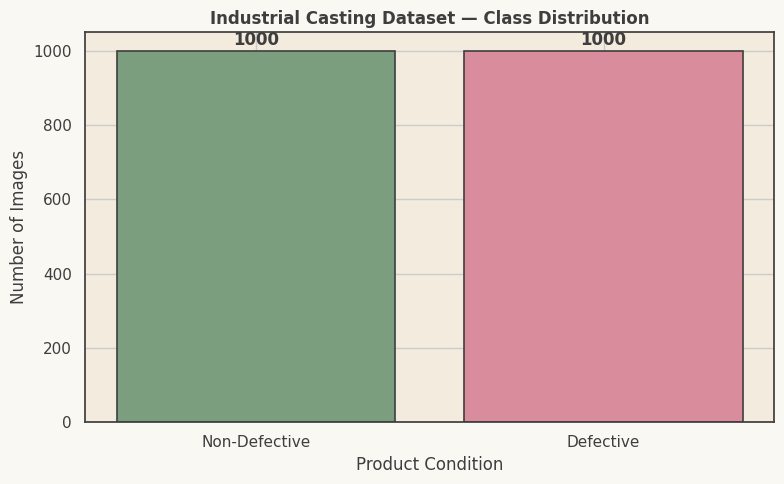

In [11]:
# ============================================================
# CHUNK 11: CLASS DISTRIBUTION
# ============================================================

class_counts = df["class_name"].value_counts().reindex(
    ["Non-Defective", "Defective"]
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_counts.index,
    class_counts.values,
    color=[SAGE, PINK],
    edgecolor=DARK,
    linewidth=1.2
)

plt.title("Industrial Casting Dataset — Class Distribution")
plt.xlabel("Product Condition")
plt.ylabel("Number of Images")

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

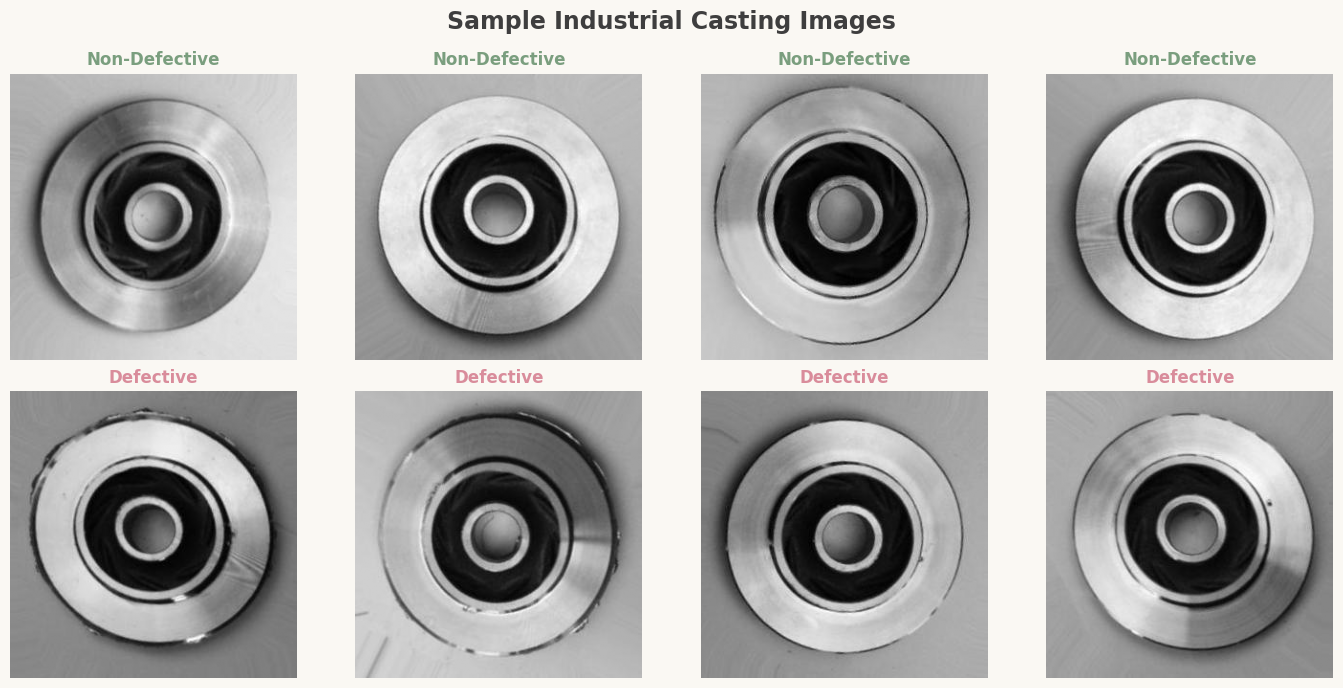

In [12]:
# ============================================================
# CHUNK 12: DISPLAY SAMPLE INDUSTRIAL IMAGES
# ============================================================

def show_samples(dataframe, samples_per_class=4):

    fig, axes = plt.subplots(
        2,
        samples_per_class,
        figsize=(14, 7)
    )

    for row, class_name in enumerate(
        ["Non-Defective", "Defective"]
    ):

        class_df = dataframe[
            dataframe["class_name"] == class_name
        ].sample(
            samples_per_class,
            random_state=SEED
        )

        for col, (_, row_data) in enumerate(class_df.iterrows()):

            image = Image.open(row_data["path"]).convert("L")

            axes[row, col].imshow(
                image,
                cmap="gray"
            )

            axes[row, col].set_title(
                class_name,
                color=SAGE if row == 0 else PINK,
                fontweight="bold"
            )

            axes[row, col].axis("off")

    plt.suptitle(
        "Sample Industrial Casting Images",
        fontsize=17,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


show_samples(df)

In [13]:
# ============================================================
# CHUNK 13: IMAGE PREPROCESSING
# ============================================================

IMAGE_SIZE = (64, 64)

def preprocess_image(image_path):
    """
    Load image, convert to grayscale,
    resize to a common resolution,
    and normalize pixel values.
    """

    image = Image.open(image_path).convert("L")

    image = image.resize(
        IMAGE_SIZE,
        Image.Resampling.LANCZOS
    )

    image = np.asarray(
        image,
        dtype=np.float32
    ) / 255.0

    return image


# Test preprocessing on one image
test_image = preprocess_image(df.iloc[0]["path"])

print("Original image size:", Image.open(df.iloc[0]["path"]).size)
print("Processed image size:", test_image.shape)
print("Minimum pixel value:", test_image.min())
print("Maximum pixel value:", test_image.max())

Original image size: (300, 300)
Processed image size: (64, 64)
Minimum pixel value: 0.0
Maximum pixel value: 0.95686275


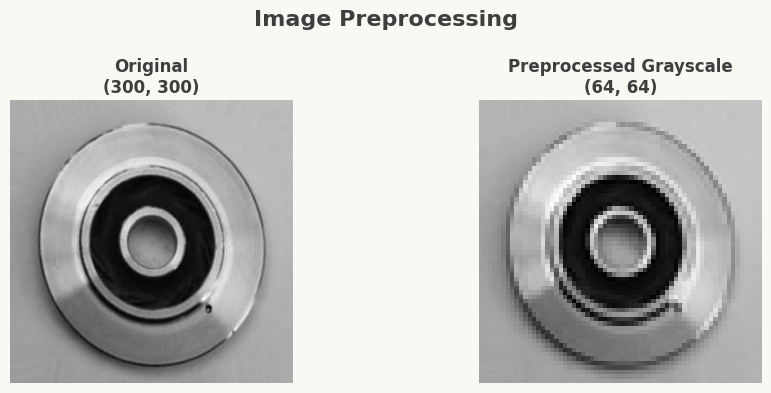

In [14]:
# ============================================================
# CHUNK 14: PREPROCESSING VISUALIZATION
# ============================================================

original = Image.open(
    df.iloc[0]["path"]
).convert("L")

processed = preprocess_image(
    df.iloc[0]["path"]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)

axes[0].imshow(
    original,
    cmap="gray"
)

axes[0].set_title(
    f"Original\n{original.size}",
    fontweight="bold"
)

axes[0].axis("off")


axes[1].imshow(
    processed,
    cmap="gray"
)

axes[1].set_title(
    f"Preprocessed Grayscale\n{IMAGE_SIZE}",
    fontweight="bold"
)

axes[1].axis("off")

plt.suptitle(
    "Image Preprocessing",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CHUNK 15: HOG FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_hog_features(
    image,
    cell_size=8,
    orientations=9
):

    features, hog_image = hog(
        image,
        orientations=orientations,
        pixels_per_cell=(cell_size, cell_size),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True,
        transform_sqrt=True,
        feature_vector=True
    )

    return features, hog_image

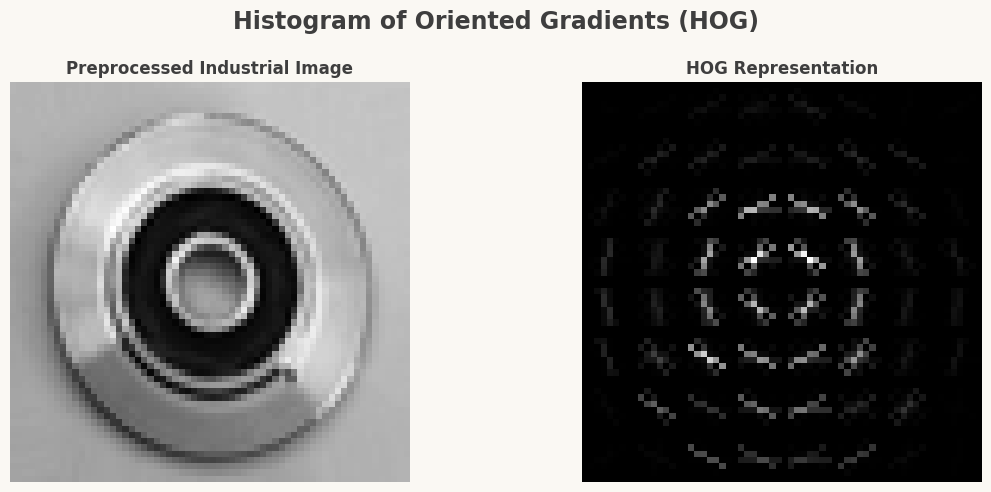

HOG feature vector length: 1764


In [17]:
# ============================================================
# CHUNK 16: HOG VISUALIZATION
# ============================================================

sample_path = df[
    df["class_name"] == "Defective"
].iloc[0]["path"]

sample_image = preprocess_image(sample_path)

hog_features, hog_image = extract_hog_features(
    sample_image,
    cell_size=8,
    orientations=9
)

hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(
    sample_image,
    cmap="gray"
)

axes[0].set_title(
    "Preprocessed Industrial Image",
    fontweight="bold"
)

axes[0].axis("off")


axes[1].imshow(
    hog_image_rescaled,
    cmap="gray"
)

axes[1].set_title(
    "HOG Representation",
    fontweight="bold"
)

axes[1].axis("off")

plt.suptitle(
    "Histogram of Oriented Gradients (HOG)",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("HOG feature vector length:", len(hog_features))

In [18]:
# ============================================================
# CHUNK 17: TRAIN-TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Testing images:", len(test_df))

print("\nTraining class distribution:")
print(train_df["class_name"].value_counts())

print("\nTesting class distribution:")
print(test_df["class_name"].value_counts())

Training images: 1600
Testing images: 400

Training class distribution:
class_name
Defective        800
Non-Defective    800
Name: count, dtype: int64

Testing class distribution:
class_name
Non-Defective    200
Defective        200
Name: count, dtype: int64


In [19]:
# ============================================================
# CHUNK 18: EXTRACT HOG FEATURES FOR TRAINING AND TESTING
# ============================================================

def build_hog_dataset(dataframe, cell_size=8, orientations=9):

    features = []
    labels = []

    for _, row in dataframe.iterrows():

        image = preprocess_image(row["path"])

        hog_features, _ = extract_hog_features(
            image,
            cell_size=cell_size,
            orientations=orientations
        )

        features.append(hog_features)
        labels.append(row["label"])

    return np.array(features), np.array(labels)


print("Extracting training HOG features...")

X_train, y_train = build_hog_dataset(
    train_df,
    cell_size=8,
    orientations=9
)

print("Extracting testing HOG features...")

X_test, y_test = build_hog_dataset(
    test_df,
    cell_size=8,
    orientations=9
)

print("\nHOG extraction completed.")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Extracting training HOG features...
Extracting testing HOG features...

HOG extraction completed.
X_train shape: (1600, 1764)
X_test shape: (400, 1764)


In [20]:
# ============================================================
# CHUNK 19: HOG + SVM
# ============================================================

svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        SVC(
            kernel="rbf",
            C=10,
            probability=True,
            random_state=SEED
        )
    )
])

print("Training SVM...")

svm_model.fit(
    X_train,
    y_train
)

print("SVM training completed.")

Training SVM...
SVM training completed.


In [21]:
# ============================================================
# CHUNK 20: HOG + RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [24]:
# ============================================================
# CHUNK 21: MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Non-Defective",
                "Defective"
            ],
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }, predictions

In [25]:
# ============================================================
# CHUNK 22: EVALUATE BOTH CLASSIFIERS
# ============================================================

svm_results, svm_predictions = evaluate_model(
    svm_model,
    X_test,
    y_test,
    "HOG + SVM"
)

rf_results, rf_predictions = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "HOG + Random Forest"
)

results_df = pd.DataFrame([
    svm_results,
    rf_results
])

display(results_df)

HOG + SVM
Accuracy : 0.9625
Precision: 0.9695
Recall   : 0.9550
F1-score : 0.9622

Classification Report:
               precision    recall  f1-score   support

Non-Defective       0.96      0.97      0.96       200
    Defective       0.97      0.95      0.96       200

     accuracy                           0.96       400
    macro avg       0.96      0.96      0.96       400
 weighted avg       0.96      0.96      0.96       400

HOG + Random Forest
Accuracy : 0.8575
Precision: 0.8667
Recall   : 0.8450
F1-score : 0.8557

Classification Report:
               precision    recall  f1-score   support

Non-Defective       0.85      0.87      0.86       200
    Defective       0.87      0.84      0.86       200

     accuracy                           0.86       400
    macro avg       0.86      0.86      0.86       400
 weighted avg       0.86      0.86      0.86       400



,Model,Accuracy,Precision,Recall,F1-Score
0,HOG + SVM,0.9625,0.969543,0.955,0.962217
1,HOG + Random Forest,0.8575,0.866667,0.845,0.855696


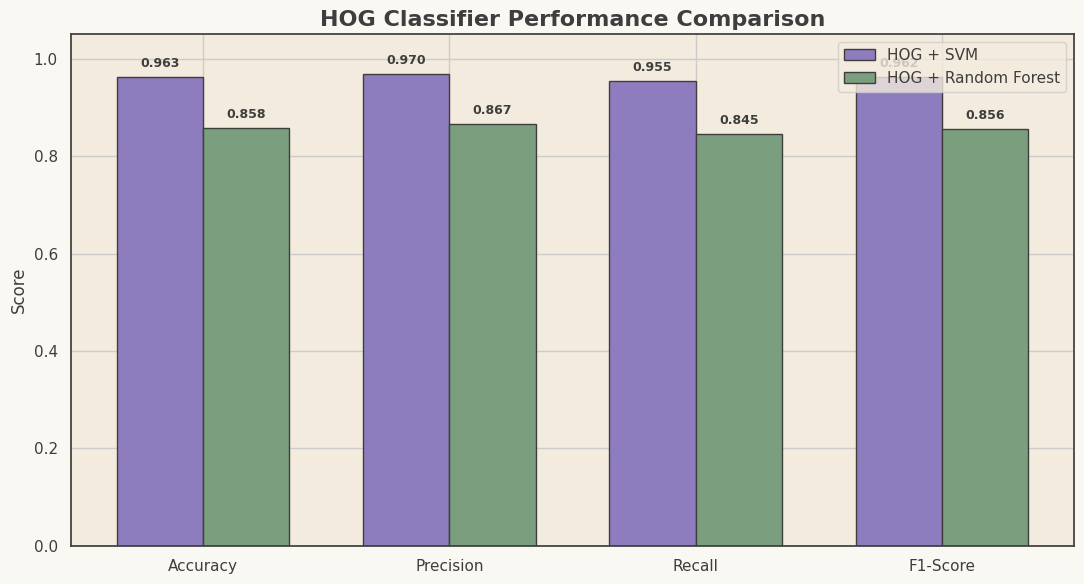

In [26]:
# ============================================================
# CHUNK 23: CLASSIFIER PERFORMANCE COMPARISON
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(
    figsize=(11, 6)
)

svm_values = results_df.iloc[0][metrics].values
rf_values = results_df.iloc[1][metrics].values

bars1 = ax.bar(
    x - width / 2,
    svm_values,
    width,
    label="HOG + SVM",
    color=PURPLE,
    edgecolor=DARK
)

bars2 = ax.bar(
    x + width / 2,
    rf_values,
    width,
    label="HOG + Random Forest",
    color=SAGE,
    edgecolor=DARK
)

ax.set_title(
    "HOG Classifier Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)

ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

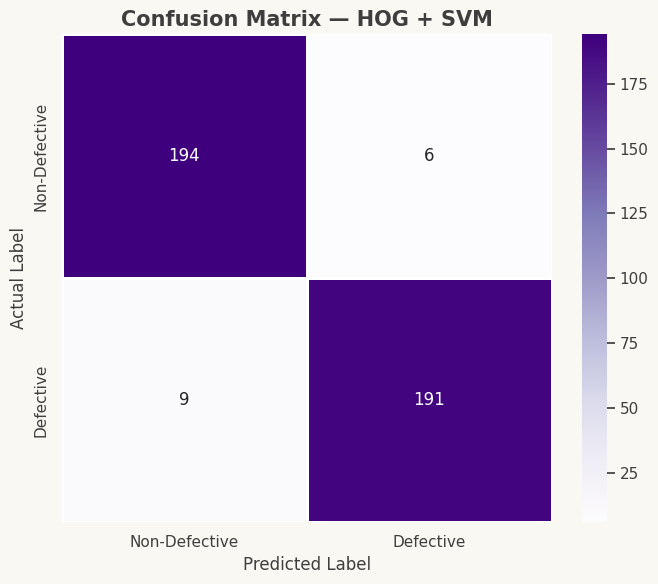

In [27]:
# ============================================================
# CHUNK 24: SVM CONFUSION MATRIX
# ============================================================

svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    linewidths=1,
    linecolor="white",
    xticklabels=[
        "Non-Defective",
        "Defective"
    ],
    yticklabels=[
        "Non-Defective",
        "Defective"
    ]
)

plt.title(
    "Confusion Matrix — HOG + SVM",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

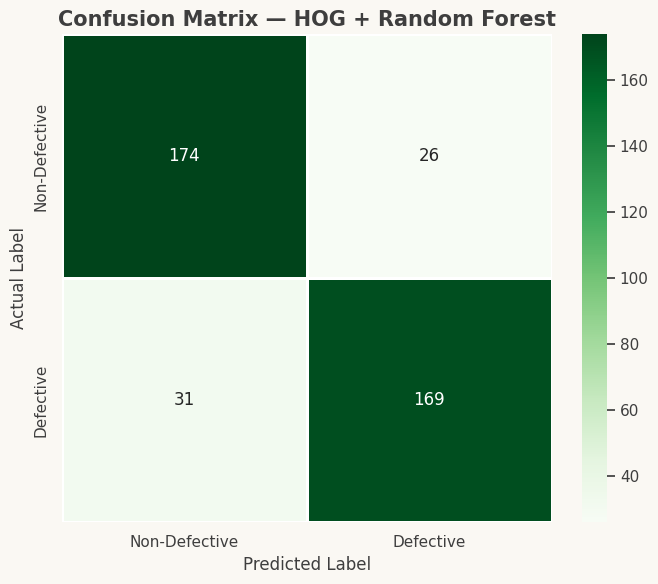

In [28]:
# ============================================================
# CHUNK 25: RANDOM FOREST CONFUSION MATRIX
# ============================================================

rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=1,
    linecolor="white",
    xticklabels=[
        "Non-Defective",
        "Defective"
    ],
    yticklabels=[
        "Non-Defective",
        "Defective"
    ]
)

plt.title(
    "Confusion Matrix — HOG + Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# CHUNK 26: HOG PARAMETER EXPERIMENT
# ============================================================

CELL_SIZES = [4, 8, 16]
ORIENTATIONS = [6, 9, 12]

hog_parameter_results = []

for cell_size in CELL_SIZES:

    for orientation in ORIENTATIONS:

        print(
            f"Testing cell={cell_size}x{cell_size}, "
            f"orientations={orientation}"
        )

        X_train_param, y_train_param = build_hog_dataset(
            train_df,
            cell_size=cell_size,
            orientations=orientation
        )

        X_test_param, y_test_param = build_hog_dataset(
            test_df,
            cell_size=cell_size,
            orientations=orientation
        )

        model = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "classifier",
                SVC(
                    kernel="rbf",
                    C=10,
                    probability=True,
                    random_state=SEED
                )
            )
        ])

        model.fit(
            X_train_param,
            y_train_param
        )

        predictions = model.predict(
            X_test_param
        )

        hog_parameter_results.append({
            "Cell Size": f"{cell_size}x{cell_size}",
            "Orientations": orientation,
            "Feature Length": X_train_param.shape[1],
            "Accuracy": accuracy_score(
                y_test_param,
                predictions
            ),
            "Precision": precision_score(
                y_test_param,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test_param,
                predictions,
                zero_division=0
            ),
            "F1-Score": f1_score(
                y_test_param,
                predictions,
                zero_division=0
            )
        })

hog_parameter_df = pd.DataFrame(
    hog_parameter_results
)

print("\nHOG parameter experiment completed.")

display(
    hog_parameter_df.sort_values(
        "F1-Score",
        ascending=False
    )
)

Testing cell=4x4, orientations=6
Testing cell=4x4, orientations=9
Testing cell=4x4, orientations=12
Testing cell=8x8, orientations=6
Testing cell=8x8, orientations=9
Testing cell=8x8, orientations=12
Testing cell=16x16, orientations=6
Testing cell=16x16, orientations=9
Testing cell=16x16, orientations=12

HOG parameter experiment completed.


,Cell Size,Orientations,Feature Length,Accuracy,Precision,Recall,F1-Score
3,8x8,6,1176,0.9650,0.974490,0.955,0.964646
4,8x8,9,1764,0.9625,0.969543,0.955,0.962217
5,8x8,12,2352,0.9525,0.954774,0.950,0.952381
1,4x4,9,8100,0.9525,0.973822,0.930,0.951407
0,4x4,6,5400,0.9475,0.973545,0.920,0.946015
7,16x16,9,324,0.9425,0.968254,0.915,0.940874
2,4x4,12,10800,0.9400,0.963158,0.915,0.938462
8,16x16,12,432,0.9325,0.952880,0.910,0.930946
6,16x16,6,216,0.9275,0.943005,0.910,0.926209


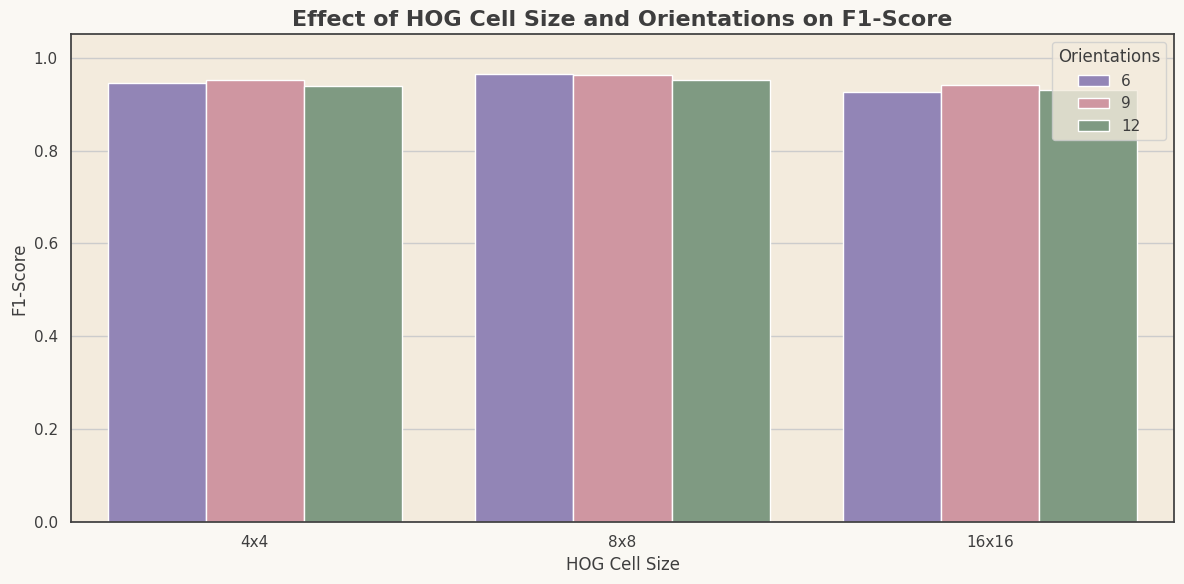

In [32]:
# ============================================================
# CHUNK 27: HOG PARAMETER COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=hog_parameter_df,
    x="Cell Size",
    y="F1-Score",
    hue="Orientations",
    palette=[
        PURPLE,
        PINK,
        SAGE
    ]
)

plt.title(
    "Effect of HOG Cell Size and Orientations on F1-Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("HOG Cell Size")
plt.ylabel("F1-Score")

plt.ylim(0, 1.05)

plt.legend(
    title="Orientations"
)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# CHUNK 28: BEST HOG CONFIGURATION
# ============================================================

best_hog = hog_parameter_df.sort_values(
    "F1-Score",
    ascending=False
).iloc[0]

print("BEST HOG CONFIGURATION")
print("=" * 40)

print(
    "Cell Size:",
    best_hog["Cell Size"]
)

print(
    "Orientations:",
    int(best_hog["Orientations"])
)

print(
    "Feature Length:",
    int(best_hog["Feature Length"])
)

print(
    f"Accuracy: {best_hog['Accuracy']:.4f}"
)

print(
    f"Precision: {best_hog['Precision']:.4f}"
)

print(
    f"Recall: {best_hog['Recall']:.4f}"
)

print(
    f"F1-Score: {best_hog['F1-Score']:.4f}"
)

BEST HOG CONFIGURATION
Cell Size: 8x8
Orientations: 6
Feature Length: 1176
Accuracy: 0.9650
Precision: 0.9745
Recall: 0.9550
F1-Score: 0.9646


In [34]:
# ============================================================
# CHUNK 29: ROBUSTNESS SETTINGS
# ============================================================

best_cell_size = int(
    str(best_hog["Cell Size"]).split("x")[0]
)

best_orientations = int(
    best_hog["Orientations"]
)

print("Best cell size:", best_cell_size)
print("Best orientations:", best_orientations)

Best cell size: 8
Best orientations: 6


In [35]:
# ============================================================
# CHUNK 30: ROBUSTNESS TRANSFORMATIONS
# ============================================================

def apply_brightness(image):
    """
    Increase brightness.
    """

    pil_image = Image.fromarray(
        (image * 255).astype(np.uint8)
    )

    enhancer = ImageEnhance.Brightness(
        pil_image
    )

    result = enhancer.enhance(1.35)

    return np.asarray(
        result,
        dtype=np.float32
    ) / 255.0


def apply_gaussian_noise(image):
    """
    Add Gaussian noise.
    """

    noise = np.random.normal(
        0,
        0.08,
        image.shape
    )

    noisy = image + noise

    return np.clip(
        noisy,
        0,
        1
    )


def apply_rotation(image):
    """
    Rotate image by a small realistic angle.
    """

    pil_image = Image.fromarray(
        (image * 255).astype(np.uint8)
    )

    rotated = pil_image.rotate(
        10,
        resample=Image.Resampling.BILINEAR
    )

    return np.asarray(
        rotated,
        dtype=np.float32
    ) / 255.0


def apply_blur(image):
    """
    Apply Gaussian-style blur.
    """

    pil_image = Image.fromarray(
        (image * 255).astype(np.uint8)
    )

    blurred = pil_image.filter(
        ImageFilter.GaussianBlur(radius=1.5)
    )

    return np.asarray(
        blurred,
        dtype=np.float32
    ) / 255.0

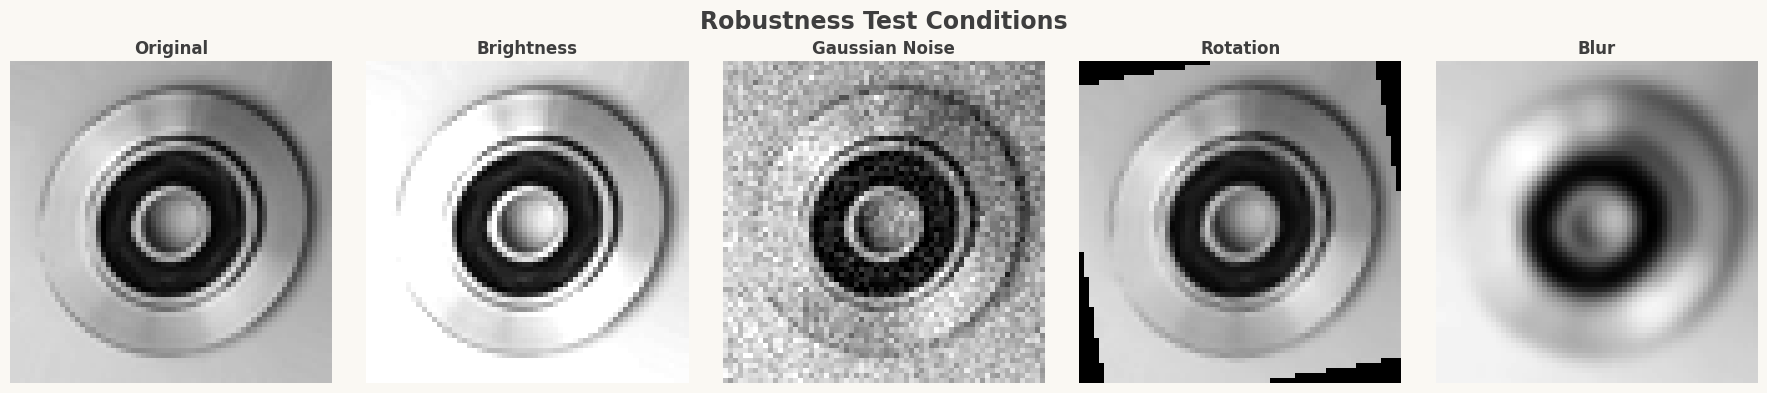

In [36]:
# ============================================================
# CHUNK 31: ROBUSTNESS VISUALIZATION
# ============================================================

robust_sample = preprocess_image(
    test_df.iloc[0]["path"]
)

robust_images = {
    "Original": robust_sample,
    "Brightness": apply_brightness(robust_sample),
    "Gaussian Noise": apply_gaussian_noise(robust_sample),
    "Rotation": apply_rotation(robust_sample),
    "Blur": apply_blur(robust_sample)
}

fig, axes = plt.subplots(
    1,
    5,
    figsize=(18, 4)
)

for ax, (title, image) in zip(
    axes,
    robust_images.items()
):

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        title,
        fontweight="bold"
    )

    ax.axis("off")

plt.suptitle(
    "Robustness Test Conditions",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# CHUNK 32: ROBUSTNESS EVALUATION
# ============================================================

def evaluate_robustness(
    model,
    dataframe,
    cell_size,
    orientations
):

    transformations = {
        "Original": lambda img: img,
        "Brightness": apply_brightness,
        "Gaussian Noise": apply_gaussian_noise,
        "Rotation": apply_rotation,
        "Blur": apply_blur
    }

    robustness_results = []

    for condition, transform in transformations.items():

        features = []
        labels = []

        for _, row in dataframe.iterrows():

            image = preprocess_image(
                row["path"]
            )

            transformed = transform(image)

            hog_features, _ = extract_hog_features(
                transformed,
                cell_size=cell_size,
                orientations=orientations
            )

            features.append(hog_features)
            labels.append(row["label"])

        features = np.array(features)
        labels = np.array(labels)

        predictions = model.predict(
            features
        )

        robustness_results.append({
            "Condition": condition,
            "Accuracy": accuracy_score(
                labels,
                predictions
            ),
            "Precision": precision_score(
                labels,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                labels,
                predictions,
                zero_division=0
            ),
            "F1-Score": f1_score(
                labels,
                predictions,
                zero_division=0
            )
        })

        print(
            f"{condition} completed."
        )

    return pd.DataFrame(
        robustness_results
    )

In [38]:
# ============================================================
# CHUNK 33: TRAIN BEST HOG + SVM
# ============================================================

X_train_best, y_train_best = build_hog_dataset(
    train_df,
    cell_size=best_cell_size,
    orientations=best_orientations
)

X_test_best, y_test_best = build_hog_dataset(
    test_df,
    cell_size=best_cell_size,
    orientations=best_orientations
)

best_svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        SVC(
            kernel="rbf",
            C=10,
            probability=True,
            random_state=SEED
        )
    )
])

best_svm_model.fit(
    X_train_best,
    y_train_best
)

print("Best HOG + SVM model trained.")

Best HOG + SVM model trained.


In [39]:
# ============================================================
# CHUNK 34: RUN ROBUSTNESS EXPERIMENT
# ============================================================

robustness_df = evaluate_robustness(
    best_svm_model,
    test_df,
    best_cell_size,
    best_orientations
)

display(
    robustness_df
)

Original completed.
Brightness completed.
Gaussian Noise completed.
Rotation completed.
Blur completed.


,Condition,Accuracy,Precision,Recall,F1-Score
0,Original,0.9650,0.974490,0.955,0.964646
1,Brightness,0.9025,0.874419,0.940,0.906024
2,Gaussian Noise,0.5000,0.500000,1.000,0.666667
3,Rotation,0.5000,0.500000,1.000,0.666667
4,Blur,0.5175,0.508906,1.000,0.674536


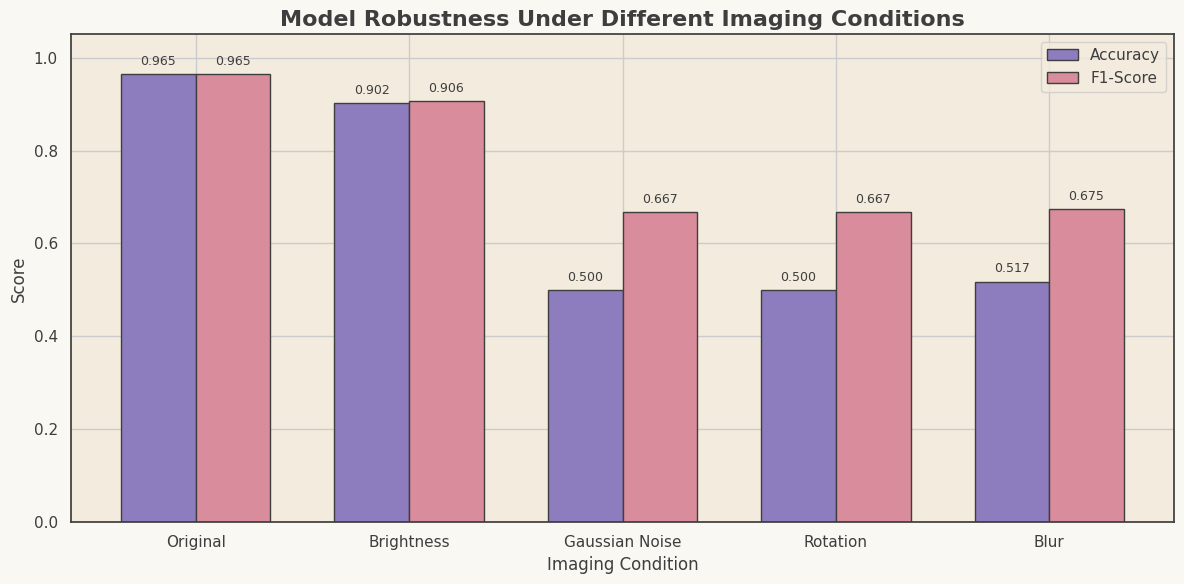

In [40]:
# ============================================================
# CHUNK 35: ROBUSTNESS RESULTS VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

x = np.arange(
    len(robustness_df)
)

width = 0.35

accuracy_bars = plt.bar(
    x - width / 2,
    robustness_df["Accuracy"],
    width,
    label="Accuracy",
    color=PURPLE,
    edgecolor=DARK
)

f1_bars = plt.bar(
    x + width / 2,
    robustness_df["F1-Score"],
    width,
    label="F1-Score",
    color=PINK,
    edgecolor=DARK
)

plt.xticks(
    x,
    robustness_df["Condition"]
)

plt.ylabel("Score")
plt.xlabel("Imaging Condition")

plt.title(
    "Model Robustness Under Different Imaging Conditions",
    fontsize=16,
    fontweight="bold"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

for bars in [accuracy_bars, f1_bars]:

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# CHUNK 36: ROBUSTNESS PERFORMANCE CHANGE
# ============================================================

baseline_accuracy = robustness_df.loc[
    robustness_df["Condition"] == "Original",
    "Accuracy"
].iloc[0]

baseline_f1 = robustness_df.loc[
    robustness_df["Condition"] == "Original",
    "F1-Score"
].iloc[0]

robustness_df["Accuracy Change"] = (
    robustness_df["Accuracy"]
    - baseline_accuracy
)

robustness_df["F1 Change"] = (
    robustness_df["F1-Score"]
    - baseline_f1
)

display(
    robustness_df
)

,Condition,Accuracy,Precision,Recall,F1-Score,Accuracy Change,F1 Change
0,Original,0.9650,0.974490,0.955,0.964646,0.0000,0.000000
1,Brightness,0.9025,0.874419,0.940,0.906024,-0.0625,-0.058622
2,Gaussian Noise,0.5000,0.500000,1.000,0.666667,-0.4650,-0.297980
3,Rotation,0.5000,0.500000,1.000,0.666667,-0.4650,-0.297980
4,Blur,0.5175,0.508906,1.000,0.674536,-0.4475,-0.290110


In [42]:
# ============================================================
# CHUNK 37: FINAL INDUSTRIAL QUALITY-CONTROL DECISION
# ============================================================

def inspect_product(
    image_path,
    model,
    cell_size,
    orientations
):

    image = preprocess_image(
        image_path
    )

    features, _ = extract_hog_features(
        image,
        cell_size=cell_size,
        orientations=orientations
    )

    features = features.reshape(
        1,
        -1
    )

    prediction = model.predict(
        features
    )[0]

    probabilities = model.predict_proba(
        features
    )[0]

    confidence = probabilities[
        prediction
    ] * 100

    if prediction == 1:
        label = "DEFECTIVE"
        action = "REJECT PRODUCT"
    else:
        label = "NON-DEFECTIVE"
        action = "ACCEPT PRODUCT"

    print("=" * 50)
    print("       PRODUCT INSPECTION RESULT")
    print("=" * 50)

    print(f"Prediction : {label}")
    print(f"Confidence : {confidence:.2f}%")
    print(f"Action     : {action}")

    print("=" * 50)

    return {
        "prediction": label,
        "confidence": confidence,
        "action": action
    }

In [43]:
# ============================================================
# CHUNK 38: TEST FINAL INSPECTION
# ============================================================

test_image_path = test_df.iloc[0]["path"]

final_result = inspect_product(
    test_image_path,
    best_svm_model,
    best_cell_size,
    best_orientations
)

print("\nTest image:")
print(test_image_path)

       PRODUCT INSPECTION RESULT
Prediction : NON-DEFECTIVE
Confidence : 62.39%
Action     : ACCEPT PRODUCT

Test image:
/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train/ok_front/cast_ok_0_1655.jpeg


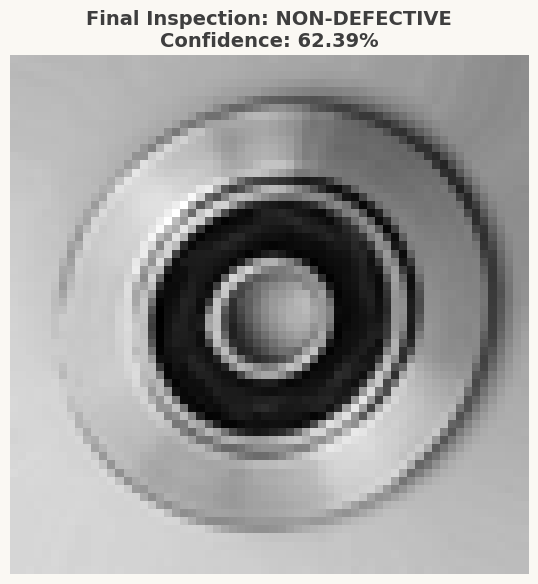

In [44]:
# ============================================================
# CHUNK 39: DISPLAY INSPECTED PRODUCT
# ============================================================

inspection_image = preprocess_image(
    test_image_path
)

plt.figure(figsize=(6, 6))

plt.imshow(
    inspection_image,
    cmap="gray"
)

plt.title(
    f"Final Inspection: {final_result['prediction']}\n"
    f"Confidence: {final_result['confidence']:.2f}%",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# CHUNK 40: FINAL EXPERIMENT SUMMARY
# ============================================================

print("=" * 70)
print("LAB 05 — FINAL EXPERIMENT SUMMARY")
print("=" * 70)

print("\nDataset:")
print("Casting Product Image Data for Quality Inspection")

print("\nImage preprocessing:")
print("Resize: 64 x 64")
print("Grayscale: Yes")

print("\nMain HOG configuration:")
print(f"Cell size: {best_cell_size} x {best_cell_size}")
print(f"Orientations: {best_orientations}")

print("\nClassifiers:")
print("1. HOG + SVM")
print("2. HOG + Random Forest")

print("\nRobustness conditions:")
print("1. Brightness variation")
print("2. Gaussian noise")
print("3. Rotation")
print("4. Blur")

print("\nBest HOG result:")
print(
    hog_parameter_df
    .sort_values("F1-Score", ascending=False)
    .iloc[0]
    .to_dict()
)

print("\nClassifier comparison:")
display(results_df)

print("\nRobustness results:")
display(robustness_df)

LAB 05 — FINAL EXPERIMENT SUMMARY

Dataset:
Casting Product Image Data for Quality Inspection

Image preprocessing:
Resize: 64 x 64
Grayscale: Yes

Main HOG configuration:
Cell size: 8 x 8
Orientations: 6

Classifiers:
1. HOG + SVM
2. HOG + Random Forest

Robustness conditions:
1. Brightness variation
2. Gaussian noise
3. Rotation
4. Blur

Best HOG result:
{'Cell Size': '8x8', 'Orientations': 6, 'Feature Length': 1176, 'Accuracy': 0.965, 'Precision': 0.9744897959183674, 'Recall': 0.955, 'F1-Score': 0.9646464646464646}

Classifier comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,HOG + SVM,0.9625,0.969543,0.955,0.962217
1,HOG + Random Forest,0.8575,0.866667,0.845,0.855696



Robustness results:


,Condition,Accuracy,Precision,Recall,F1-Score,Accuracy Change,F1 Change
0,Original,0.9650,0.974490,0.955,0.964646,0.0000,0.000000
1,Brightness,0.9025,0.874419,0.940,0.906024,-0.0625,-0.058622
2,Gaussian Noise,0.5000,0.500000,1.000,0.666667,-0.4650,-0.297980
3,Rotation,0.5000,0.500000,1.000,0.666667,-0.4650,-0.297980
4,Blur,0.5175,0.508906,1.000,0.674536,-0.4475,-0.290110
